# Project Dataset : "Auto Price Prediction"
Domain: Auto Mobile

# Problem Statment :

# Import Libraries :

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset :

In [2]:
df=pd.read_csv(r"D:\datasets\Internship_Projects\Auto_Mobile_Price_Data\auto_imports.csv")
df.head()

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


In [3]:
# columns = [
#     "Symboling", "Normalized-Losses", "Company-name", "Fuel-type", "Aspiration", "Body-style", "Drive-wheels",
#           "Engine-location", "Wheel-base", "Length", "Width", "Height", "Curb-weight", "Engine-type", "Num-of-cylinders",
#           "Engine-size", "Fuel-system", "Bore", "Stroke", "Compression-ratio", "Horsepower", "Peak-rpm",
#           "City-mpg", "Highway-mpg", "Price",]

In [4]:
columns = [
    "Symboling", "Normalized-Losses","Company-name","Fuel-type","Aspiration","Num-of-doors",
    "Body-style","Drive-wheels","Engine-location","Wheel-base","Length","Width","Height","Curb-weight",
    "Engine-type","Num-of-cylinders","Engine-size","Fuel-system","Bore","Stroke","Compression-ratio",
    "Horsepower","Peak-rpm","City-mpg","Highway-mpg","Price"]

In [5]:
df = pd.read_csv(r"D:\datasets\Internship_Projects\Auto_Mobile_Price_Data\auto_imports.csv",
                 names=columns,na_values="?")
df.head()

,Symboling,Normalized-Losses,Company-name,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,...,Engine-size,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


# Explanation :
        > Load my CSV
        > Give it the correct Columan names
        > Convert ? into Missing values
        > Save everything as "df"."

In [6]:
df.shape

(201, 26)

> Rows : 200
> Columns : 26

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Symboling          201 non-null    int64  
 1   Normalized-Losses  164 non-null    float64
 2   Company-name       201 non-null    str    
 3   Fuel-type          201 non-null    str    
 4   Aspiration         201 non-null    str    
 5   Num-of-doors       199 non-null    str    
 6   Body-style         201 non-null    str    
 7   Drive-wheels       201 non-null    str    
 8   Engine-location    201 non-null    str    
 9   Wheel-base         201 non-null    float64
 10  Length             201 non-null    float64
 11  Width              201 non-null    float64
 12  Height             201 non-null    float64
 13  Curb-weight        201 non-null    int64  
 14  Engine-type        201 non-null    str    
 15  Num-of-cylinders   201 non-null    str    
 16  Engine-size        201 non-null    in

In [8]:
df.describe(include="all")

,Symboling,Normalized-Losses,Company-name,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,...,Engine-size,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price
count,201.000000,164.000000,201,201,201,199,201,201,201,201.000000,...,201.000000,201,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
unique,NaN,NaN,22,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,181,165,113,94,118,198,NaN,...,NaN,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.840796,122.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.797015,...,126.875622,NaN,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,35.442168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.066366,...,41.546834,NaN,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,98.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000


In [9]:
df.isnull().sum()[df.isnull().sum()>0]

Normalized-Losses    37
Num-of-doors          2
Bore                  4
Stroke                4
Horsepower            2
Peak-rpm              2
dtype: int64

# EDA (Explotry Data Analysis):

# Heatmap :  "Correlation of Features"

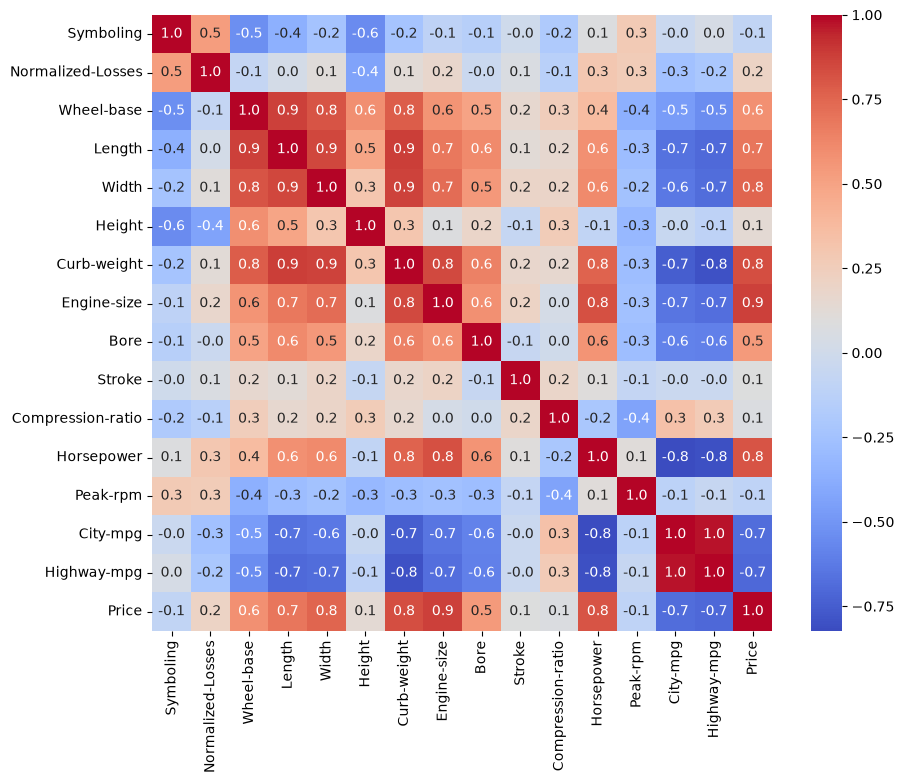

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.show()

# Target Variable(Sales Price) Analysis :

# Histogram : "Distribution of Cars Sales Price"

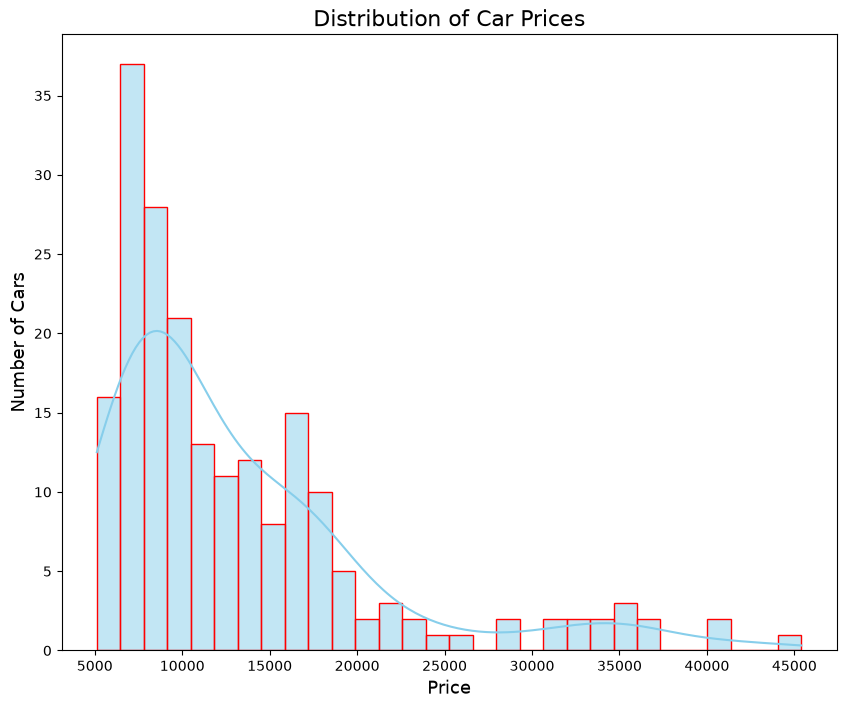

In [11]:
plt.figure(figsize=(10,8))

sns.histplot(
    data=df,
    x="Price",
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="red"
)

plt.title("Distribution of Car Prices",fontsize=16)
plt.xlabel("Price",fontsize=13)
plt.ylabel("Number of Cars",fontsize=13)

plt.show()

# Explanation :
        "This graph shows how many cars fall into different price ranges. The Price Distribution helps us understand the overall spread of automobile prices and identify skewmess and potential extreme values."

* Important Info:

- Most Cars Price -> Between 5000-20000 Price Range
- Few Cars Price -> Very Expensive Range

# Boxplot : "Outlier Detection of Price"

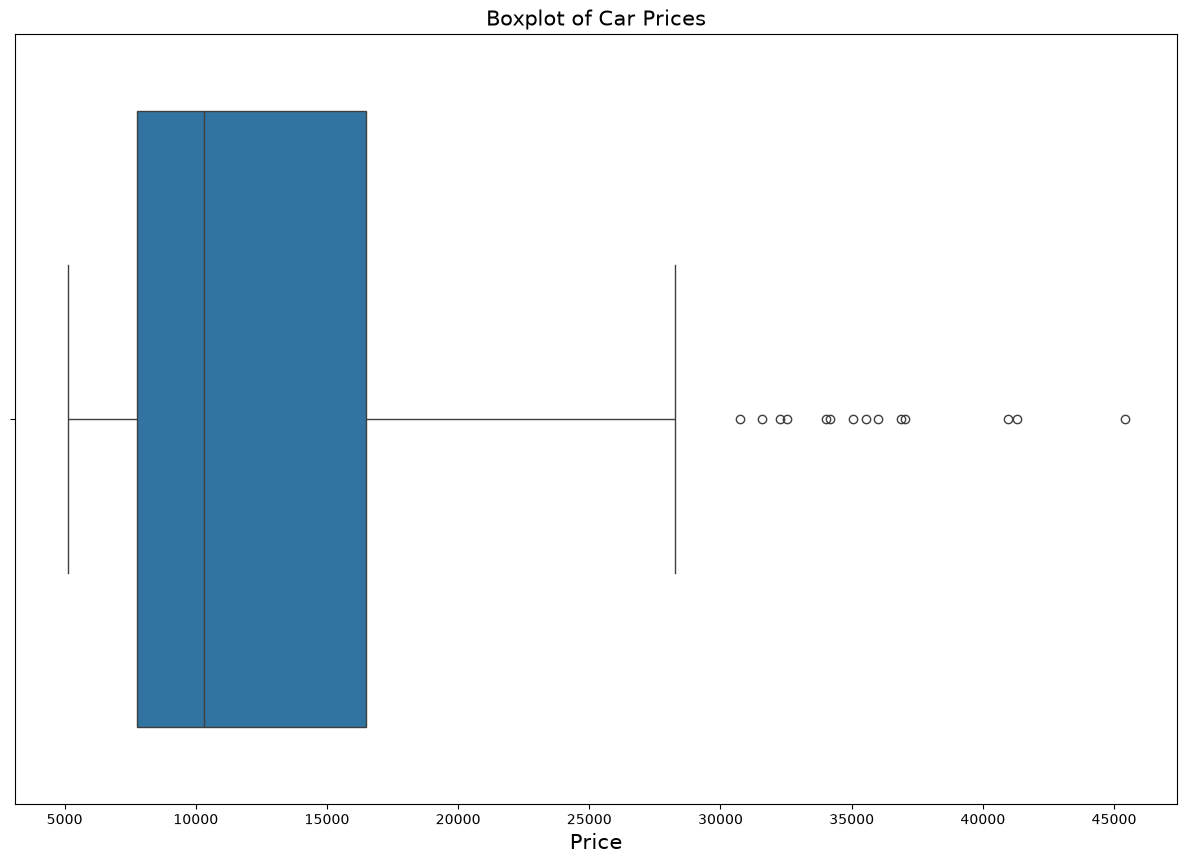

In [12]:
plt.figure(figsize=(15,10))

sns.boxplot(x=df["Price"])

plt.title("Boxplot of Car Prices",fontsize=15)
plt.xlabel("Price",fontsize=15)

plt.show()

# Explanation :
        "The Boxplot helps identify unusually high or loe prices.In Our Dataset Mostly Car Prices range in between from 5000 to 30000 but some few cars are expensive may be their are Luxury Cars which More than Price Range."

# Car Company vs Price :

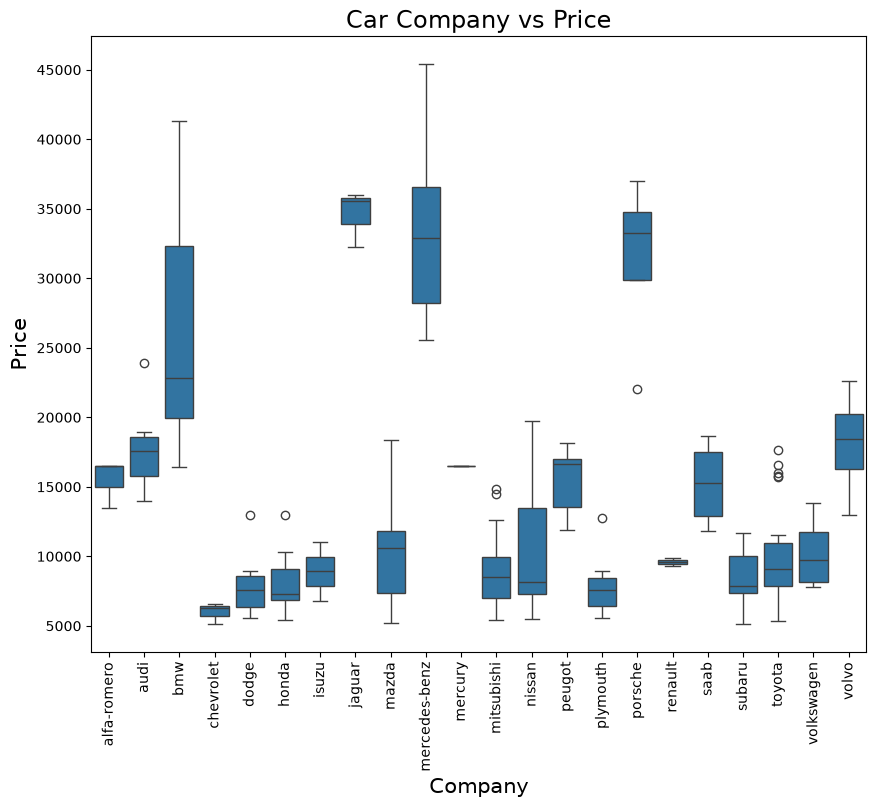

In [13]:
plt.figure(figsize=(10,8))

sns.boxplot(
    data=df,
    x="Company-name",
    y="Price"
)

plt.xticks(rotation=90)

plt.title("Car Company vs Price",fontsize=17)
plt.xlabel("Company",fontsize=15)
plt.ylabel("Price",fontsize=15)

plt.show()

# Explanation :
        "This compares prices of different automobile companies."

Importatnt Info :

* Companies with Generally Lower Prices : "Chevrolet, Dodge, Honda, Isuzu, Mazda, Mitsubishi, Nissan, Plymouth, Renault, Subaru, Toyota, Volkswagen"

* Companies with Generally Higher Prices : "Alfa-Romero, Audi, BMW, Jaguar, Mercedes-benz, Mercury, Peugot, Saab, Volvo"

# Scatterplot : "Engine Size vs Price"

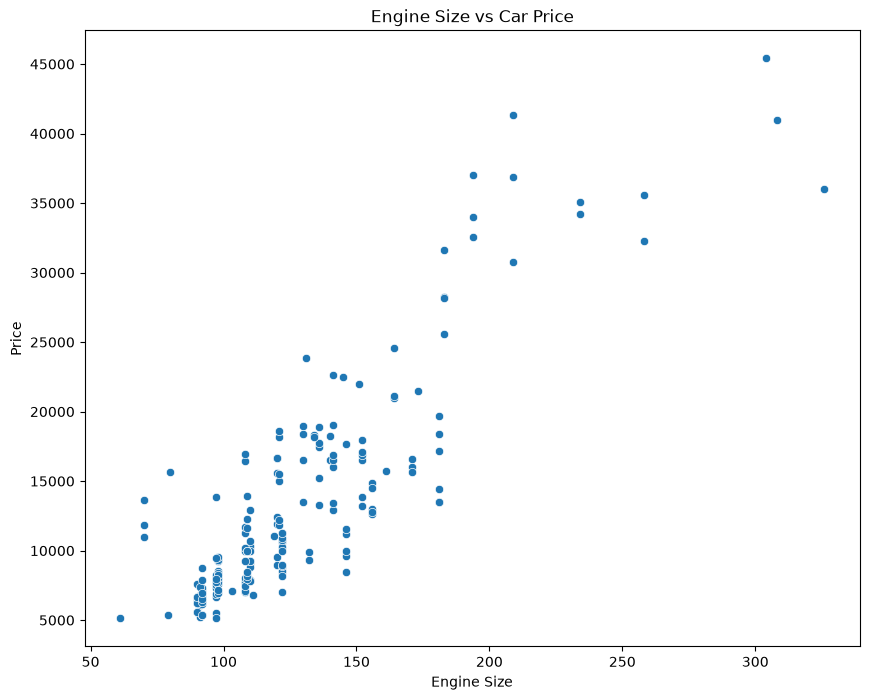

In [14]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df,
    x="Engine-size",
    y="Price"
)

plt.title("Engine Size vs Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.show()

# Explanation :
> A scatter plot puts each car as one dot.

- X-axis -> Engine Size
- Y-axis -> Price
- Each dot -> One car

> Impotant info:

    "As per Engine Size Changes, The Sale Price also Changes.If the dots generally move upward from left to right."
    
    Engine Size ↑
          ↓
    Price tends  ↑